# PricePilot AI - EDA 1
## Product Catalog & Historical Sales

**Milestone 1 contribution:** understand the available product and sales data, check data quality, and identify initial pricing and sales patterns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path('../data/PricePilot_8_Small_Datasets.xlsx')
products = pd.read_excel(DATA, sheet_name='01_Product_Catalog')
sales = pd.read_excel(DATA, sheet_name='02_Historical_Sales')
sales['date'] = pd.to_datetime(sales['date'])
products.head(), sales.head()

Matplotlib is building the font cache; this may take a moment.


(  product_id product_name       category  cost_price  list_price
 0       P001   Product 01  Running Shoes    15607.06    22548.16
 1       P002   Product 02    Smartphones    38077.86    47818.08
 2       P003   Product 03     Headphones    29547.76    38910.20
 3       P004   Product 04        Laptops    24347.68    32785.24
 4       P005   Product 05  Smart Watches     7084.73     9794.13,
         date product_id  selling_price  discount_pct  units_sold    revenue
 0 2026-05-01       P001       21420.75             5           7  149945.26
 1 2026-05-02       P001       19165.94            15           9  172493.42
 2 2026-05-03       P001       22548.16             0           9  202933.44
 3 2026-05-04       P001       22548.16             0           8  180385.28
 4 2026-05-05       P001       22548.16             0           7  157837.12)

In [2]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 12.4 MB/s eta 0:00:0031m13.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 10.7 MB/s eta 0:00:00 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 13.1 MB/s eta 0:00:00 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 10.4 MB/s eta 0:00:00 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 11.2 MB/s eta 0:00:000:00:01m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11/11 [matplotlib]0m 10/11 [matplotlib]tools]

[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip


## 1. Dataset overview

In [2]:
print('Product catalog shape:', products.shape)
print('Historical sales shape:', sales.shape)
print('Sales period:', sales['date'].min().date(), 'to', sales['date'].max().date())
print('Unique products in sales:', sales['product_id'].nunique())
print('Categories:', products['category'].nunique())
print('\nProduct columns:', products.columns.tolist())
print('Sales columns:', sales.columns.tolist())

Product catalog shape: (20, 5)
Historical sales shape: (1800, 6)
Sales period: 2026-05-01 to 2026-07-29
Unique products in sales: 20
Categories: 5

Product columns: ['product_id', 'product_name', 'category', 'cost_price', 'list_price']
Sales columns: ['date', 'product_id', 'selling_price', 'discount_pct', 'units_sold', 'revenue']


## 2. Data quality checks

In [4]:
print('Missing values - Product Catalog')
print(products.isna().sum())
print('\nMissing values - Historical Sales')
print(sales.isna().sum())
print('\nDuplicate rows')
print('Product Catalog:', products.duplicated().sum())
print('Historical Sales:', sales.duplicated().sum())
print('\nData types')
print(sales.dtypes)

Missing values - Product Catalog
product_id      0
product_name    0
category        0
cost_price      0
list_price      0
dtype: int64

Missing values - Historical Sales
date             0
product_id       0
selling_price    0
discount_pct     0
units_sold       0
revenue          0
dtype: int64

Duplicate rows
Product Catalog: 0
Historical Sales: 0

Data types
date             datetime64[us]
product_id                  str
selling_price           float64
discount_pct              int64
units_sold                int64
revenue                 float64
dtype: object


## 3. Product-level analysis

In [5]:
product_summary = products.copy()
product_summary['gross_margin_pct'] = (product_summary['list_price'] - product_summary['cost_price']) / product_summary['list_price'] * 100
print(product_summary.groupby('category').agg(products=('product_id','count'), avg_cost=('cost_price','mean'), avg_list_price=('list_price','mean'), avg_margin_pct=('gross_margin_pct','mean')).round(2))

               products  avg_cost  avg_list_price  avg_margin_pct
category                                                         
Headphones            4  29814.85        38856.94           22.66
Laptops               4  18979.57        27217.31           31.24
Running Shoes         4   8161.61        12073.65           32.45
Smart Watches         4  14037.17        18625.88           27.47
Smartphones           4  23258.76        29560.86           21.93


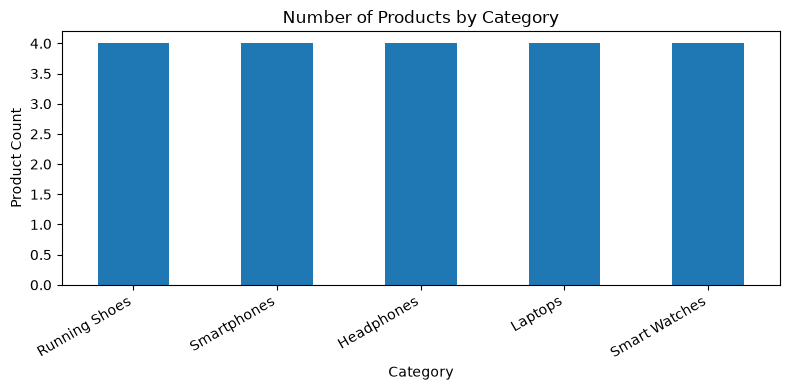

In [6]:
category_counts = products['category'].value_counts()
category_counts.plot(kind='bar', figsize=(8,4))
plt.title('Number of Products by Category')
plt.xlabel('Category')
plt.ylabel('Product Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 4. Historical sales analysis

In [7]:
sales_summary = sales.agg(total_units=('units_sold','sum'), total_revenue=('revenue','sum'), avg_selling_price=('selling_price','mean'), avg_discount=('discount_pct','mean'))
print(sales_summary.round(2))
print('\nSales by category:')
sales_cat = sales.merge(products[['product_id','category']], on='product_id').groupby('category').agg(units_sold=('units_sold','sum'), revenue=('revenue','sum'), avg_selling_price=('selling_price','mean'), avg_discount=('discount_pct','mean')).sort_values('revenue', ascending=False)
print(sales_cat.round(2))

                   units_sold       revenue  selling_price  discount_pct
total_units           27777.0           NaN            NaN           NaN
total_revenue             NaN  6.497171e+08            NaN           NaN
avg_selling_price         NaN           NaN       24131.26           NaN
avg_discount              NaN           NaN            NaN          4.55

Sales by category:
               units_sold       revenue  avg_selling_price  avg_discount
category                                                                
Headphones           5610  2.229917e+08           37245.80          4.17
Laptops              6727  1.747716e+08           25965.71          4.64
Smartphones          4957  1.106638e+08           28080.32          5.03
Smart Watches        5013  9.017113e+07           17800.61          4.58
Running Shoes        5470  5.111881e+07           11563.88          4.32


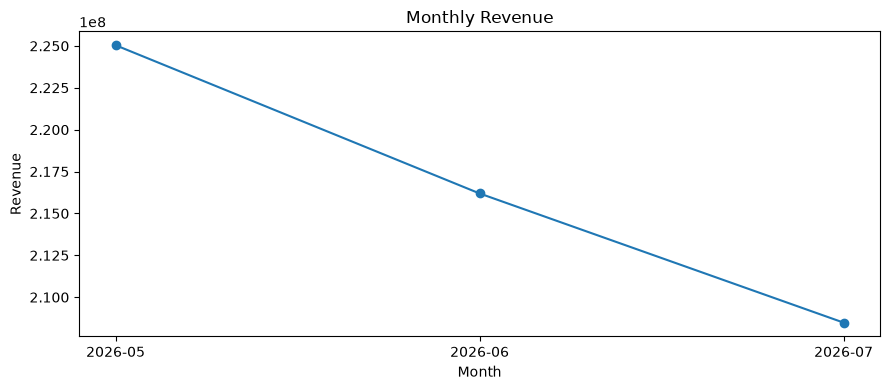

In [8]:
monthly = sales.assign(month=sales['date'].dt.to_period('M').astype(str)).groupby('month').agg(units_sold=('units_sold','sum'), revenue=('revenue','sum'), avg_selling_price=('selling_price','mean')).reset_index()
fig, ax = plt.subplots(figsize=(9,4))
ax.plot(monthly['month'], monthly['revenue'], marker='o')
ax.set_title('Monthly Revenue')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue')
plt.tight_layout()
plt.show()

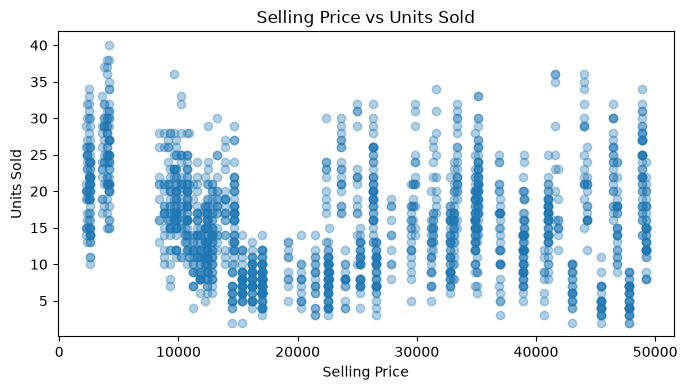

Correlation: -0.113


In [9]:
fig, ax = plt.subplots(figsize=(7,4))
ax.scatter(sales['selling_price'], sales['units_sold'], alpha=0.35)
ax.set_title('Selling Price vs Units Sold')
ax.set_xlabel('Selling Price')
ax.set_ylabel('Units Sold')
plt.tight_layout()
plt.show()
print('Correlation:', round(sales['selling_price'].corr(sales['units_sold']), 3))

## 5. Initial findings

- The product catalog contains 20 products across 5 categories.
- Historical sales contains 1,800 records covering May 1 to July 29, 2026.
- No missing values or duplicate rows were found in the two analyzed sheets.
- Headphones generated the highest category revenue in the supplied data, while Laptops recorded the highest units sold.
- Selling price and units sold show a weak negative linear relationship in this dataset, so pricing decisions should consider additional demand drivers rather than price alone.
- The analysis provides a clean baseline for the next stage: integrating inventory, competitor prices, promotions, seasonal events, and market indicators.

In [10]:
print('EDA 1 completed successfully.')

EDA 1 completed successfully.
